In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
iris = datasets.load_iris()
X=iris.data[:, :2]
Y=iris.target

X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
kernels = {
    "Linear" : SVC(kernel="linear", C=1.0),
    "Polynomial": SVC(kernel="poly",degree=3, C=1.0),
    "RBF" : SVC(kernel="rbf", gamma='scale', C=1.0),
    "Sigmoid":SVC(kernel="sigmoid", C=1.0)
}
def plot_svm(X, y, model, title):
    h = 0.2

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k')

    plt.title(title)
    plt.show()

   

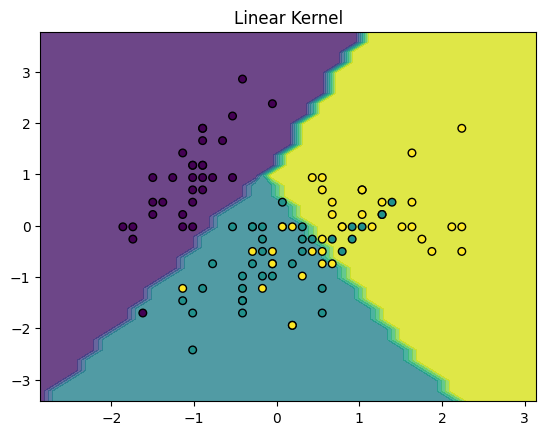

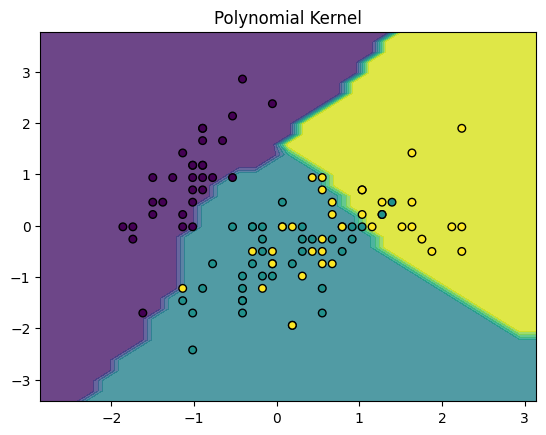

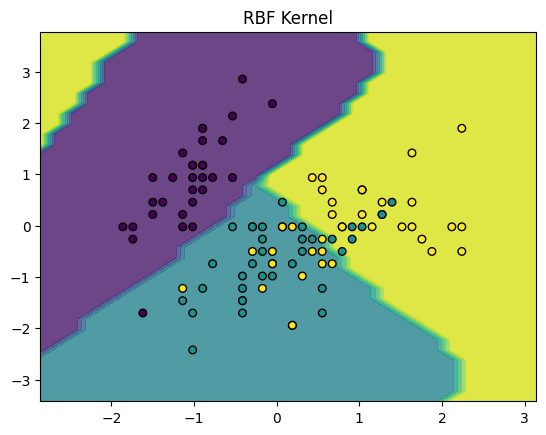

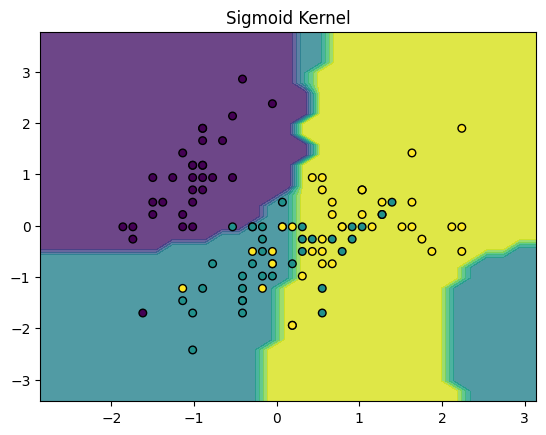

In [15]:
 accuracy_results={}

 for name,model in kernels.items():
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test,y_pred)
        accuracy_results[name] = acc

        plot_svm(X_train, y_train, model, f"{name} Kernel")

In [18]:
print("Kernel Accuracy Comparison:")

for k, v in accuracy_results.items():
    print(f"{k} Kernel Accuracy: {v:.2f}")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Kernel Accuracy Comparison:
Linear Kernel Accuracy: 0.73
Polynomial Kernel Accuracy: 0.76
RBF Kernel Accuracy: 0.73
Sigmoid Kernel Accuracy: 0.78
Confusion Matrix:
 [[19  0  0]
 [ 1  5  7]
 [ 0  2 11]]
